In [ ]:
# First import packages
from acoli import acoli_hist
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from PIL import Image

# Question 1
## Question 1a.

In a function of two variables, the number of tangent lines possible at any point in its domain is infinite.

## Question 1b.

Given a surface with points $(x, y, f(x, y))$, the gradient is computed by

$$
\left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y} \right)
$$

As such, it is a 2-dimensional vector. To plot it into \(\mathbb{R}^3\), you plot it using the coordinates

$$
\left( \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}, f(x,y) \right)
$$


## Question 1c.
The directional derivative find the amount changes in a given direction. The gradient is related to the directional derivative because the gradient find the amount a functions changes in a specific direction: more accutately, the direction of steepest ascent (greatest change).

## Question 1d.
The gradient always points to the direction of steepest ascent. Since you are climbing a mountain, the goal is to reach the top of the mountain, or the point of highest elevation. If you deviate from the gradient, any step taken not in the direction of the gradient will get you to a point that is not as high as the gradient. Therefore, you will have to take additional steps to reach the same elevation had you gone in the gradient's direction, leading to a longer path.


# Question 2
## Question 2a.

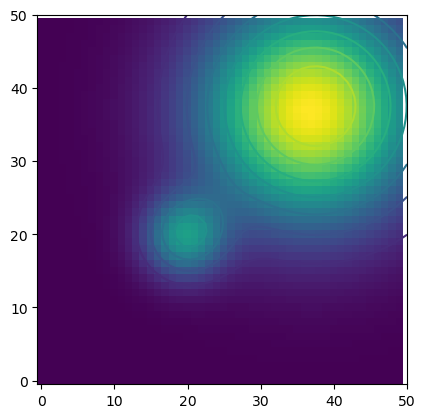

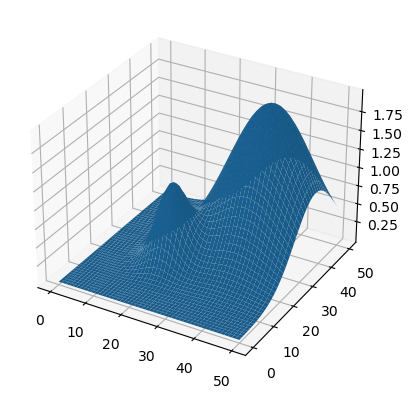

In [17]:
initpos = [0, 0]
foodfn = 2
rttp = 0.5
ttrp = 0.5
ntrials = 2
nsteps = 10
nbins = 50
visualize=False
verbose=False
foodfn = 2


X = np.linspace(0, nbins, nbins)
Y = np.linspace(0, nbins, nbins)

histm, food = acoli_hist(initpos, foodfn, rttp, ttrp, ntrials, nsteps, nbins, visualize=False, verbose=False)

# Heat Map
plt.imshow(food, origin='lower')

# Contour Plot
plt.contour(X, Y, food)

# 3D Surface Plot
gridx, gridy = np.meshgrid(X, Y)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(gridx, gridy, food)

## Question 2b.

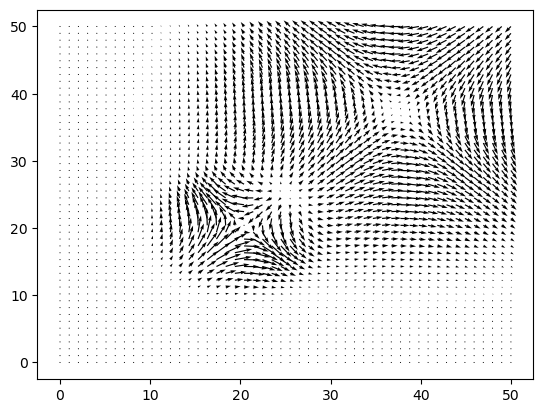

In [10]:
# Gradient Vector Field Plot
gradx, grady = np.gradient(food)
plt.quiver(X, Y, gradx, grady)

The gradient function takes in a values (in this food) and calculates the gradient along the x and y axis.

## Question 2c.

### What happens when both are low?
When both RTTP and TTRP are low, the movement it takes will often stay the same. If it is running, it will take a while for it to run/tumble again, and if it is tumbling, it will take a couple trials for it to run/tumble again.
### What happens when both are high?
When both RTTP and TTRP are low, the movement it takes is more random. Instead of always choosing to run or always choosing to tumble, it will switch off randomly between the two.
### What happens when one is high, the other is low?
When one is high and the other is low, it will tend to choose the one with the higher probability.
### How many steps does it take?
~ 50 steps

## Question 2d.

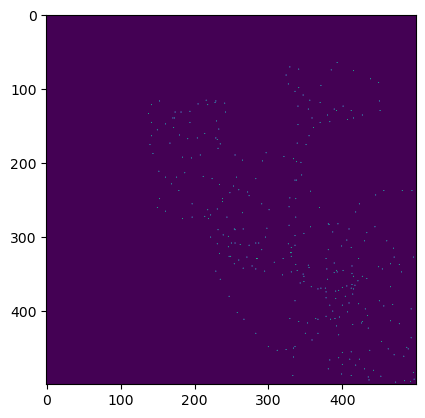

In [10]:
# Visualizing histograms with different numbers of bins
initpos = [0, 0]
foodfn = 2
rttp = 0.5
ttrp = 0.5
ntrials = 2
nsteps = 200
nbins = 500
visualize=False
verbose=False
foodfn = 2

histm, food = acoli_hist(initpos, foodfn, rttp, ttrp, ntrials, nsteps, nbins, visualize=False, verbose=False)
plt.imshow(histm)

### Are more bins always better? 
More bins are not always better. This is because as the number of bins contineus to increase, it harder to see the trend of where the acoli goes, as the bins the acoli visits stretch out due to the increase in resolution.

## Question 2e.

In [40]:
# Initial Parameters
initpos = [0, 0]
foodfn = 1
ntrials = 100
nsteps = 200
nbins = 50
visualize=False
verbose=False

# Finding the histm and food values and putting in datatable
p_range = np.arange(0.0, 1.1, 0.1)
rows = []
for i in p_range:
    for j in p_range:
        histm, food = acoli_hist(initpos, foodfn, i, j, ntrials, nsteps, nbins, visualize=False, verbose=False)
        avg_food = np.sum(food * histm)
        row_to_add = {'RTTP and TTRP Combination': (i, j), 'Average Food Value': avg_food}
        rows.append(row_to_add)

df = pd.DataFrame(rows)

In [41]:
df
print(df.loc[df['Average Food Value'].idxmax()])


RTTP and TTRP Combination    (0.7000000000000001, 0.0)
Average Food Value                         17295.14192
Name: 77, dtype: object


A good value of RTTP and TTRP to choose is (0.7, 0.0). This yields the highest average food value of the food function.

## Question 2f.
I believe that different values may do better for function 2. Specifically, since there are two regions with food in the food function where one has more than the other, it may be better to have a higher probability of tumbling so that we can avoid local maxima and instead find the total maximum.

In [38]:
# Initial Parameters
initpos = [0, 0]
ntrials = 100
nsteps = 200
nbins = 50
visualize=False
verbose=False
foodfn = 2

# Finding the histm and food values and putting in datatable
rows2 = []
for i in p_range:
    for j in p_range:
        histm, food = acoli_hist(initpos, foodfn, i, j, ntrials, nsteps, nbins, visualize=False, verbose=False)
        avg_food = np.sum(food * histm)
        row_to_add = {'RTTP and TTRP Combination': (i, j), 'Average Food Value': avg_food}
        rows2.append(row_to_add)

df2 = pd.DataFrame(rows2)

In [39]:
df2
print(df2.loc[df2['Average Food Value'].idxmax()])

RTTP and TTRP Combination    (0.30000000000000004, 0.0)
Average Food Value                         29286.906801
Name: 33, dtype: object


## Question 2g.
A.coli's strategy is very similar to gradient ascent. In gradient ascent, gradients are continuously calculated while the position is updated at each step to move toward the direction with the largest gradient. Simlarily, the a.coli moves toward the direction with the greatest amount of food. A.coli's advantage is it has a likelihood of tumbling as well. This is beneficial because it can avoid local minima.

# Question 3
## Question 3a.

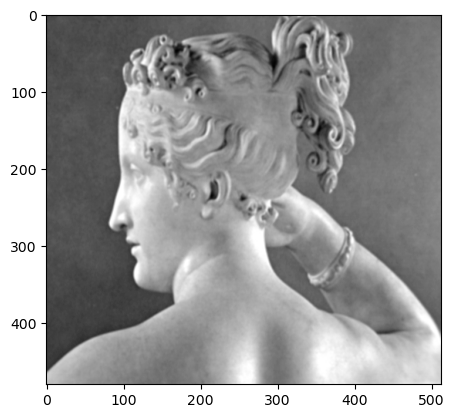

In [5]:
img = 'Paolina.tiff'
img = np.array(Image.open(img))

img = img.astype('float')/255
plt.imshow(img, cmap='gray')

## Question 3b.


(0.5, 511.5, 0.5, 479.5)

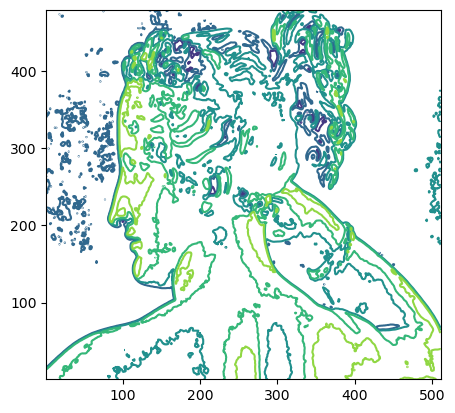

In [9]:
plt.contour(img, origin='upper')
plt.axis('image')


The contour function seems to be detecting the edges in the image.

## Question 3c.

In [20]:
img_slice = img[150:300,50:150]
img_slice = np.flip(img_slice)
# Gradient Vector Field Plot
gradx, grady = np.gradient(img_slice)
print(gradx.shape)
print(grady.shape)
# plt.quiver(gradx, grady)

(150, 100)
(150, 100)


## Question 3d.

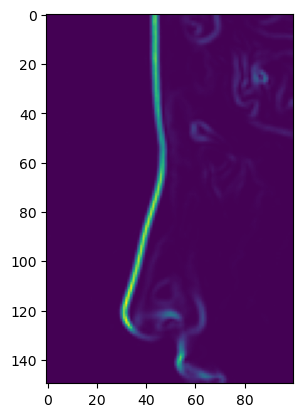

In [22]:
gmag = np.flip((gradx ** 2 + grady ** 2) ** 1/2)
plt.imshow(gmag)

The gradient seems to tell us how sharp the edges are in the image. Edges that are more defined appear in a more highlighted color as opposed to edges that are more similar to their neighboring region.

## Question 3e.

If we were to use the Paulina image as the food function, the amount of food would be dictated by the sharpness of the edges. In other words, the larger the magnitude of the gradient in a bin, the more "food" in that bin. In this case, if we started at (0,0), the a.coli would run and tumble toward her nose in the image, where the magnitude of the gradient is the largest. Then it will follow move along the nose down image.